In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Column names for the ratings dataset
rating_columns = ['user_id', 'movie_id', 'rating', 'timestamp']

# Load the ratings data
ratings = pd.read_csv("../dataset/ml-100k/u.data", sep="\t", names = rating_columns)

# Display the first 5 rows
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [6]:
ratings.head(10)


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
5,298,474,4,884182806
6,115,265,2,881171488
7,253,465,5,891628467
8,305,451,3,886324817
9,6,86,3,883603013


In [7]:
ratings.shape

(100000, 4)

In [9]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [10]:
ratings.isnull().sum()

user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

In [11]:
# Column names for the movie dataset
movie_columns = ['movie_id', 'movie_title', 'release_date', 'video_release_date','IMDb_URL', 'unknown', 'Action', 'Adventure','Animation',
    "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama','Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery','Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

# Load the movie dataset
movies = pd.read_csv("../dataset/ml-100k/u.item", sep="|", names = movie_columns, encoding ="latin-1")

# Display the first 5 rows
movies.head()

,movie_id,movie_title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children's,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [12]:
# Merge ratings and movie datasets using movie_id
movie_data = pd.merge(ratings, movies, on="movie_id")

# Display first 5 rows
movie_data.head()

,user_id,movie_id,rating,timestamp,movie_title,release_date,video_release_date,IMDb_URL,unknown,Action,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,...,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,...,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,...,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,...,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
movie_data.shape

(100000, 27)

In [14]:
# Count the number of unique users
movie_data['user_id'].nunique()

943

In [15]:
# Count the number of unique movies
movie_data['movie_id'].nunique()

1682

In [16]:
movie_data.groupby(['movie_id', 'movie_title'])['rating'].count().sort_values(ascending=False).head(10)

movie_id  movie_title                  
50        Star Wars (1977)                 583
258       Contact (1997)                   509
100       Fargo (1996)                     508
181       Return of the Jedi (1983)        507
294       Liar Liar (1997)                 485
286       English Patient, The (1996)      481
288       Scream (1996)                    478
1         Toy Story (1995)                 452
300       Air Force One (1997)             431
121       Independence Day (ID4) (1996)    429
Name: rating, dtype: int64

In [17]:
# Calculate the average rating for each movie
movie_data.groupby(['movie_id', 'movie_title'])['rating'].mean().sort_values(ascending=False).head(10)

movie_id  movie_title                                      
1189      Prefontaine (1997)                                   5.0
1500      Santa with Muscles (1996)                            5.0
1201      Marlene Dietrich: Shadow and Light (1996)            5.0
1293      Star Kid (1997)                                      5.0
1653      Entertaining Angels: The Dorothy Day Story (1996)    5.0
1122      They Made Me a Criminal (1939)                       5.0
814       Great Day in Harlem, A (1994)                        5.0
1467      Saint of Fort Washington, The (1993)                 5.0
1536      Aiqing wansui (1994)                                 5.0
1599      Someone Else's America (1995)                        5.0
Name: rating, dtype: float64

In [ ]:
# Create summary statistics for each movie
movie_stats = movie_data.groupby(['movie_id', 'movie_title'])['rating'].agg(rating_count='count', average_rating='mean')

# Display first 10 rows
movie_stats.head(10)

,,rating_count,average_rating
movie_id,movie_title,,
1,Toy Story (1995),452,3.878319
2,GoldenEye (1995),131,3.206107
3,Four Rooms (1995),90,3.033333
4,Get Shorty (1995),209,3.550239
5,Copycat (1995),86,3.302326
6,Shanghai Triad (Yao a yao yao dao waipo qiao) (1995),26,3.576923
7,Twelve Monkeys (1995),392,3.798469
8,Babe (1995),219,3.995434
9,Dead Man Walking (1995),299,3.896321


In [22]:
# Movies with at least 100 ratings and an average rating of 4.0 or higher
recommended_movies = movie_stats[(movie_stats['rating_count'] >= 100) & (movie_stats['average_rating'] >= 4.0)]

# Show the first 10 recommended movies
recommended_movies.head(10)

,,rating_count,average_rating
movie_id,movie_title,,
12,"Usual Suspects, The (1995)",267,4.385768
22,Braveheart (1995),297,4.151515
23,Taxi Driver (1976),182,4.120879
48,Hoop Dreams (1994),117,4.094017
50,Star Wars (1977),583,4.358491
56,Pulp Fiction (1994),394,4.060914
64,"Shawshank Redemption, The (1994)",283,4.445230
79,"Fugitive, The (1993)",336,4.044643
83,Much Ado About Nothing (1993),176,4.062500


In [33]:
# Sort movies by the number of ratings
top_movies = movie_stats.sort_values( by='rating_count', ascending=False)

# Display the top 10 movies
top_movies = top_movies.head(10)

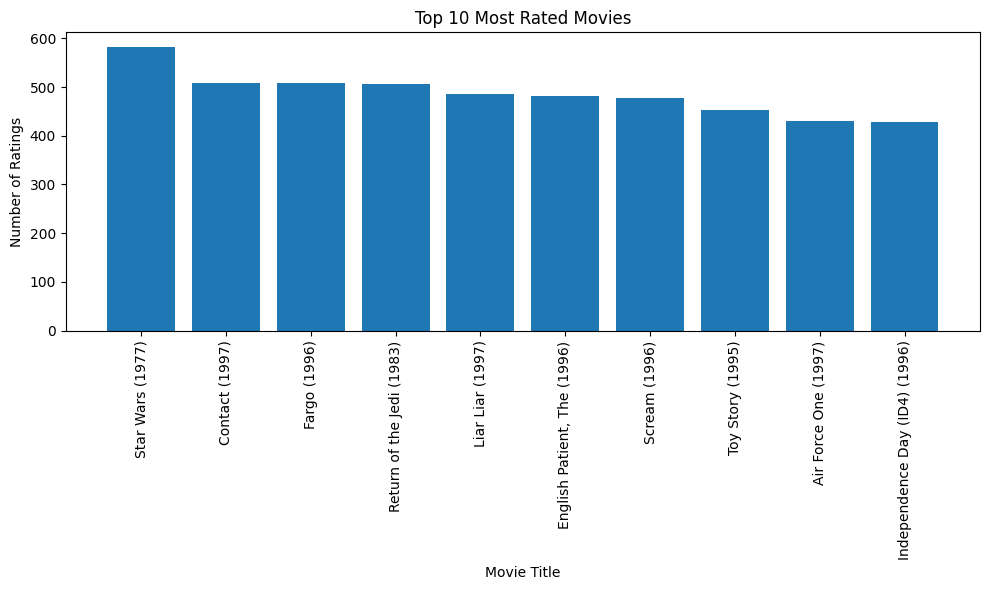

In [30]:
plt.figure(figsize=(10,6))

plt.bar(top_movies.index.get_level_values('movie_title'), top_movies['rating_count'])

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie Title")
plt.ylabel("Number of Ratings")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [32]:
# Sort movies by average rating
top_rated_movies = movie_stats.sort_values( by='average_rating', ascending=False)

# Display the top 10 movies
top_rated_movies = top_rated_movies.head(10)

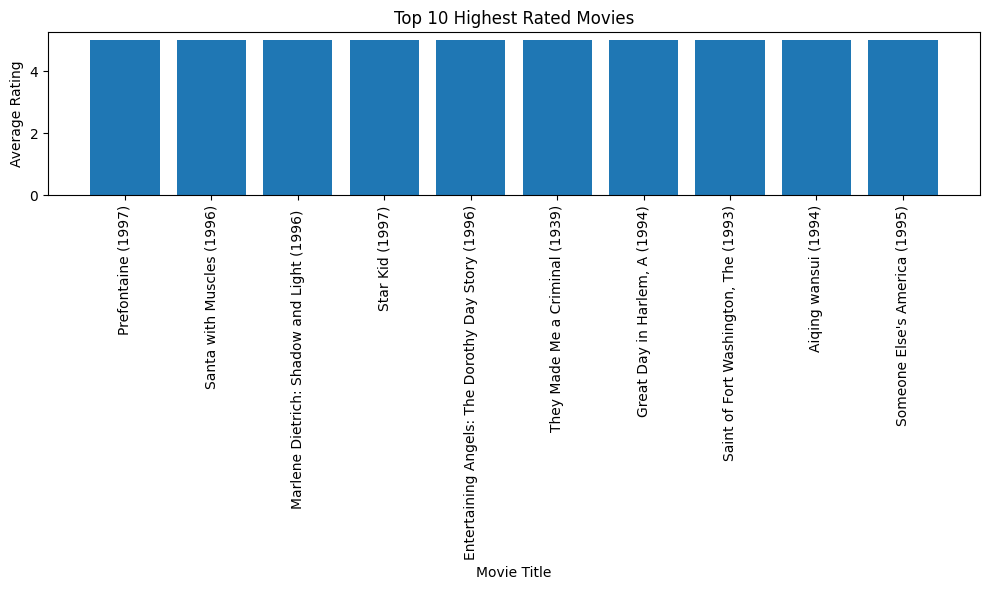

In [34]:
plt.figure(figsize=(10,6))

plt.bar(top_rated_movies.index.get_level_values('movie_title'), top_rated_movies['average_rating'])

plt.title("Top 10 Highest Rated Movies")
plt.xlabel("Movie Title")
plt.ylabel("Average Rating")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

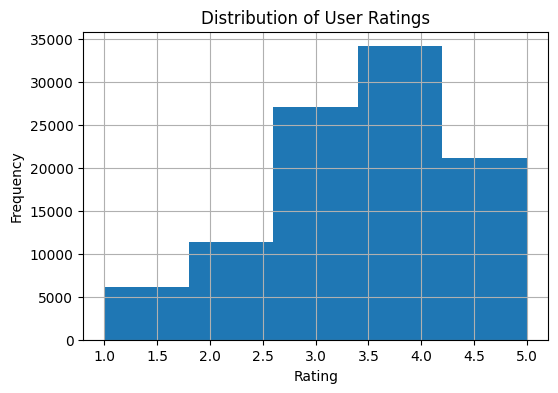

In [35]:
plt.figure(figsize=(6,4))

movie_data['rating'].hist(bins=5)

plt.title("Distribution of User Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

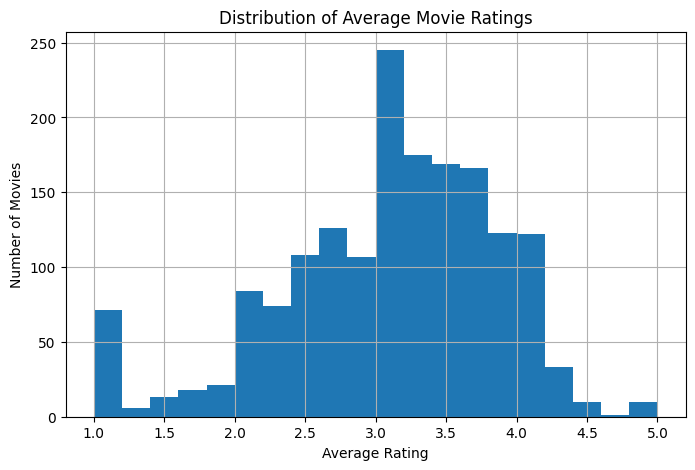

In [36]:
plt.figure(figsize=(8,5))

movie_stats['average_rating'].hist(bins=20)

plt.title("Distribution of Average Movie Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")

plt.show()

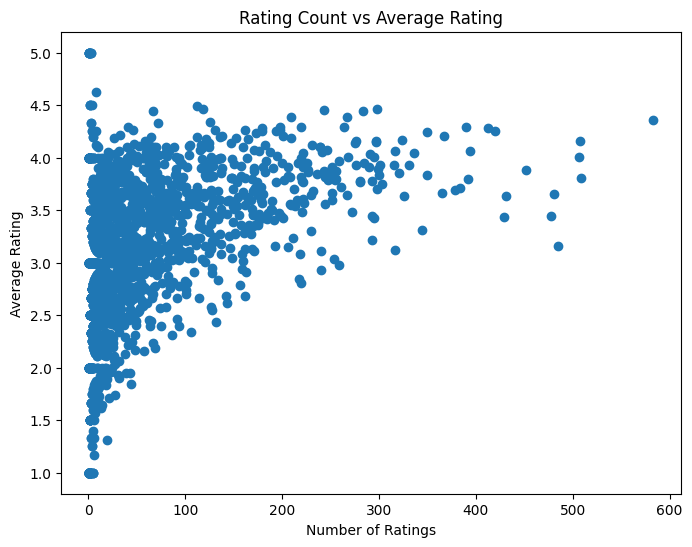

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(movie_stats['rating_count'], movie_stats['average_rating'])

plt.title("Rating Count vs Average Rating")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")

plt.show()

In [38]:
from sklearn.metrics.pairwise import cosine_similarity

In [39]:
genre_columns = ['unknown','Action','Adventure','Animation',"Children's",'Comedy',
    'Crime','Documentary','Drama','Fantasy','Film-Noir','Horror','Musical','Mystery',
    'Romance','Sci-Fi','Thriller','War','Western']

In [40]:
genre_matrix = movies[genre_columns]

# Display first 5 rows
genre_matrix.head()

,unknown,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


In [41]:
similarity_matrix = cosine_similarity(genre_matrix)

In [42]:
similarity_matrix.shape

(1682, 1682)

In [43]:
movie_indices = pd.Series(movies.index, index = movies['movie_title'])

In [45]:
movie_indices.head()

movie_title
Toy Story (1995)     0
GoldenEye (1995)     1
Four Rooms (1995)    2
Get Shorty (1995)    3
Copycat (1995)       4
dtype: int64

In [59]:
def recommend_movies(movie_title, num_recommendations=5):

    movie_index = movie_indices[movie_title]

    similarity_scores = similarity_matrix[movie_index]

    movie_scores = list(enumerate(similarity_scores))

    movie_scores = sorted(movie_scores, key=lambda x: x[1], reverse=True)

    movie_scores = movie_scores[1:num_recommendations+1]

    print("Movies similar to", movie_title)
    print("-" * 40)

    for movie in movie_scores:
        movie_name = movies.iloc[movie[0]]["movie_title"]
        print(movie_name, "- Similarity:", round(movie[1], 2))

In [60]:
recommend_movies("Toy Story (1995)")

Movies similar to Toy Story (1995)
----------------------------------------
Aladdin and the King of Thieves (1996) - Similarity: 1.0
Aladdin (1992) - Similarity: 0.87
Goofy Movie, A (1995) - Similarity: 0.87
Santa Clause, The (1994) - Similarity: 0.82
Home Alone (1990) - Similarity: 0.82


In [61]:
recommend_movies("Star Wars (1977)")

Movies similar to Star Wars (1977)
----------------------------------------
Return of the Jedi (1983) - Similarity: 1.0
Empire Strikes Back, The (1980) - Similarity: 0.91
Starship Troopers (1997) - Similarity: 0.89
African Queen, The (1951) - Similarity: 0.89
Stargate (1994) - Similarity: 0.77


In [62]:
recommend_movies("Pulp Fiction (1994)")

Movies similar to Pulp Fiction (1994)
----------------------------------------
Carlito's Way (1993) - Similarity: 1.0
GoodFellas (1990) - Similarity: 1.0
Donnie Brasco (1997) - Similarity: 1.0
Jackie Brown (1997) - Similarity: 1.0
Bonnie and Clyde (1967) - Similarity: 1.0


In [63]:
!pip install scikit-surprise

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.3 MB 1.5 MB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.3 MB 1.2 MB/s eta 0:00:01
   ------------------------------- -------- 1.0/1.3 MB 1.2 MB/s eta 0:00:01
   ------------------------------- -------- 1.0/1.3 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 1.1 MB/s  0:00:02



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

In [65]:
reader = Reader(rating_scale=(1, 5))

data = Dataset.load_from_df(ratings[['user_id', 'movie_id', 'rating']],reader)

In [66]:
trainset, testset = train_test_split(data , test_size=0.2 , random_state=42)

In [67]:
model = SVD()

In [68]:
model.fit(trainset)

In [69]:
prediction = model.predict(uid=1, iid=50)

prediction

Prediction(uid=1, iid=50, r_ui=None, est=np.float64(4.781692179985081), details={'was_impossible': False})

In [70]:
print("Predicted Rating:", round(prediction.est, 2))

Predicted Rating: 4.78


In [71]:
prediction = model.predict(uid=10, iid=100)

print("Predicted Rating:", round(prediction.est, 2))

Predicted Rating: 4.56


In [72]:
predictions = []

for movie_id in range(1, 1683):
 predicted_rating = model.predict(uid=10, iid=movie_id)
 predictions.append((movie_id, predicted_rating.est))

In [73]:
predictions[:10]

[(1, np.float64(4.022143414279805)),
 (2, np.float64(3.5955520625360267)),
 (3, np.float64(3.467233968227314)),
 (4, np.float64(4.0235350312408675)),
 (5, np.float64(3.7632284986389846)),
 (6, np.float64(3.983867653557882)),
 (7, np.float64(3.903594929004197)),
 (8, np.float64(4.494219557824476)),
 (9, np.float64(4.195273408521223)),
 (10, np.float64(4.212183212251193))]

In [74]:
predictions = sorted(predictions , key=lambda x: x[1] , reverse=True)

In [75]:
predictions[:10]

[(483, np.float64(4.891399008379501)),
 (963, np.float64(4.813295747677412)),
 (427, np.float64(4.809835960063881)),
 (484, np.float64(4.757558319561904)),
 (480, np.float64(4.75459492632503)),
 (603, np.float64(4.743914001641863)),
 (178, np.float64(4.743868086366976)),
 (496, np.float64(4.729315261888482)),
 (169, np.float64(4.7247446069739745)),
 (12, np.float64(4.686105265615165))]

In [76]:
print("Top 10 Recommended Movies for User 10")
print("-" * 50)

for movie in predictions[:10]:

    movie_id = movie[0]

    predicted_rating = round(movie[1], 2)

    movie_name = movies.loc[movies["movie_id"] == movie_id,"movie_title"].values[0]

    print(movie_name, " | Predicted Rating:", predicted_rating)

Top 10 Recommended Movies for User 10
--------------------------------------------------
Casablanca (1942)  | Predicted Rating: 4.89
Some Folks Call It a Sling Blade (1993)  | Predicted Rating: 4.81
To Kill a Mockingbird (1962)  | Predicted Rating: 4.81
Maltese Falcon, The (1941)  | Predicted Rating: 4.76
North by Northwest (1959)  | Predicted Rating: 4.75
Rear Window (1954)  | Predicted Rating: 4.74
12 Angry Men (1957)  | Predicted Rating: 4.74
It's a Wonderful Life (1946)  | Predicted Rating: 4.73
Wrong Trousers, The (1993)  | Predicted Rating: 4.72
Usual Suspects, The (1995)  | Predicted Rating: 4.69


In [86]:
def recommend_for_user(user_id, n=10):

    predictions = []
    user_rated_movies = ratings[ratings["user_id"] == user_id]["movie_id"].tolist()

    for movie_id in movies["movie_id"]:
        if movie_id in user_rated_movies:
           continue

        prediction = model.predict(uid=user_id, iid=movie_id)

        predictions.append((movie_id, prediction.est))

    predictions = sorted(predictions , key=lambda x: x[1] , reverse=True)

    print(f"\nTop {n} Recommended Movies for User {user_id}")
    print("-" * 60)

    for movie in predictions[:n]:

      movie_name = movies.loc[movies["movie_id"] == movie[0],"movie_title"].values[0]

      print(movie_name,"| Predicted Rating:", round(movie[1], 2))

In [89]:
recommend_for_user(50)


Top 10 Recommended Movies for User 50
------------------------------------------------------------
Wallace & Gromit: The Best of Aardman Animation (1996) | Predicted Rating: 4.72
Close Shave, A (1995) | Predicted Rating: 4.6
Wrong Trousers, The (1993) | Predicted Rating: 4.57
Terminator 2: Judgment Day (1991) | Predicted Rating: 4.55
Usual Suspects, The (1995) | Predicted Rating: 4.53
Casablanca (1942) | Predicted Rating: 4.51
Godfather, The (1972) | Predicted Rating: 4.48
Silence of the Lambs, The (1991) | Predicted Rating: 4.47
Manchurian Candidate, The (1962) | Predicted Rating: 4.45
North by Northwest (1959) | Predicted Rating: 4.43


In [82]:
recommend_for_user(92)


Top 10 Recommended Movies for User 92
------------------------------------------------------------
Fargo (1996) | Predicted Rating: 4.75
Usual Suspects, The (1995) | Predicted Rating: 4.64
Pulp Fiction (1994) | Predicted Rating: 4.57
Apocalypse Now (1979) | Predicted Rating: 4.57
Godfather, The (1972) | Predicted Rating: 4.55
Star Wars (1977) | Predicted Rating: 4.55
Blade Runner (1982) | Predicted Rating: 4.5
Empire Strikes Back, The (1980) | Predicted Rating: 4.5
Clockwork Orange, A (1971) | Predicted Rating: 4.47
Godfather: Part II, The (1974) | Predicted Rating: 4.45


In [90]:
# Predict ratings for the test set
predictions = model.test(testset)

# Calculate RMSE
rmse(predictions)

RMSE: 0.9343


np.float64(0.934285509431068)

In [91]:
from surprise.accuracy import mae
mae(predictions)

MAE:  0.7369


np.float64(0.7368593505608587)

In [92]:
recommend_for_user(24)


Top 10 Recommended Movies for User 24
------------------------------------------------------------
Boot, Das (1981) | Predicted Rating: 5
Rear Window (1954) | Predicted Rating: 5
Lawrence of Arabia (1962) | Predicted Rating: 4.92
Third Man, The (1949) | Predicted Rating: 4.89
Vertigo (1958) | Predicted Rating: 4.88
Sunset Blvd. (1950) | Predicted Rating: 4.87
Close Shave, A (1995) | Predicted Rating: 4.86
Grand Day Out, A (1992) | Predicted Rating: 4.83
Casablanca (1942) | Predicted Rating: 4.83
Raging Bull (1980) | Predicted Rating: 4.82


# Movie Recommendation System

## Import Libraries

## Load Dataset

## Exploratory Data Analysis

## Data Visualization

## Content-Based Recommendation

## Collaborative Filtering

## Model Evaluation

## Conclusion